### Imports

In [ ]:
!pip install -r requirements.txt

In [ ]:
from collections import deque
import heapq
from itertools import combinations, chain
import networkx as nx
import matplotlib.pyplot as plt

### Modelagem

In [119]:
def estado_to_label(estado: tuple[set, str]) -> str:
    lado, posicao_tocha = estado
    pessoas = ", ".join(str(p) for p in sorted(lado))
    return f"{{{pessoas}}}, {'1' if posicao_tocha == 'inicio' else '0'}"

class Grafo:
    def __init__(self):
        self.lista_adjacencia = {}

    def adicionar_vertice(self, vertice):
        if type(vertice) == tuple:
            vertice = estado_to_label(vertice)
        if vertice not in self.lista_adjacencia:
            self.lista_adjacencia[vertice] = {}
    
    def adicionar_aresta(self,vertice1, vertice2, custo):
        if type(vertice1) == tuple:
            vertice1 = estado_to_label(vertice1)
        if type(vertice2) == tuple:
            vertice2 = estado_to_label(vertice2)
            
        for vertice in [vertice1, vertice2]:
            if vertice not in self.lista_adjacencia:
                self.adicionar_vertice(vertice)
        self.lista_adjacencia[vertice1][vertice2] = custo

    def show(self):
        G = nx.DiGraph()
        for v1, vizinhos in self.lista_adjacencia.items():
            for v2, custo in vizinhos.items():
                G.add_edge(v1, v2, weight=custo)

        plt.figure(figsize=(25, 15))
        pos = nx.spring_layout(G, seed=42,k=2)
        nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue", font_size=12)
        labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
        plt.show(block=True)  # bloqueia a janela e permite interação

In [120]:
# Tempos das pessoas
TEMPOS = {
    'A': 1,
    'B': 2,
    'C': 5,
    'D': 10
}

# Todas as pessoas
PESSOAS = {'A', 'B', 'C', 'D'}

# Estado = (conjunto de quem está no lado inicial, lado da tocha)
estado_inicial = (set(PESSOAS), 'inicio')
estado_objetivo = (set(), 'final')

# Função para inverter o lado da tocha
def lado_oposto(lado):
    return 'final' if lado == 'inicio' else 'inicio'


def estado_to_label(estado: tuple[set, str]) -> str:
    lado, posicao_tocha = estado
    pessoas = ", ".join(str(p) for p in sorted(lado))
    return f"{{{pessoas}}}, {'1' if posicao_tocha == 'inicio' else '0'}"

print(estado_to_label(estado_inicial))
print(estado_to_label(estado_objetivo))

{A, B, C, D}, 1
{}, 0


### Função Sucessora

In [121]:
def construir_sucessores(estado):
    # Gera todos sucessores possiveis de um estado
    # retorna tuplas: (estado_novo, pessoas_movidas, custo)
    lado_inicio, tocha = estado
    sucessores = []

    if tocha == 'inicio':
        for grupo in chain(combinations(lado_inicio, 1), combinations(lado_inicio, 2)):
            grupo = set(grupo)
            novo_lado_inicio = lado_inicio - grupo
            novo_estado = (novo_lado_inicio, 'final')
            custo = max(TEMPOS[p] for p in grupo)
            sucessores.append({"estado":novo_estado,"passageiros":grupo,"custo": custo})
    
    else:  # tocha está no lado 'final'
        lado_final = PESSOAS - lado_inicio
        for pessoa in lado_final:
            grupo = {pessoa}
            novo_lado_inicio = lado_inicio | grupo
            novo_estado = (novo_lado_inicio, 'inicio')
            custo = TEMPOS[pessoa]
            sucessores.append({"estado":novo_estado,"passageiros":grupo,"custo": custo})

    return sucessores

def mostrar_caminho(caminho, custo_total):
    for i, (estado, grupo, custo) in enumerate(caminho):
        print(f"Passo {i}:")
        print(estado_to_label(estado))
        if grupo:
            print(f"Ação: {sorted(grupo)} | Custo da ação: {custo}")
        print("---")
    print(f"Custo total da travessia: {custo_total} minutos")

In [122]:
print("Sucessores do estado inicial:")
sucessores = construir_sucessores(estado_inicial)
for sucessor in sucessores:
    print(f"Ação: {sorted(sucessor["passageiros"])} | Custo: {sucessor["custo"]}")
    print(estado_to_label(sucessor["estado"]))
    print("---")


Sucessores do estado inicial:
Ação: ['D'] | Custo: 10
{A, B, C}, 0
---
Ação: ['C'] | Custo: 5
{A, B, D}, 0
---
Ação: ['B'] | Custo: 2
{A, C, D}, 0
---
Ação: ['A'] | Custo: 1
{B, C, D}, 0
---
Ação: ['C', 'D'] | Custo: 10
{A, B}, 0
---
Ação: ['B', 'D'] | Custo: 10
{A, C}, 0
---
Ação: ['A', 'D'] | Custo: 10
{B, C}, 0
---
Ação: ['B', 'C'] | Custo: 5
{A, D}, 0
---
Ação: ['A', 'C'] | Custo: 5
{B, D}, 0
---
Ação: ['A', 'B'] | Custo: 2
{C, D}, 0
---


In [123]:
def bfs_com_grafo(estado_inicial, estado_objetivo) -> Grafo:
    g = Grafo()
    fila = deque()
    fila.append((estado_inicial, [], 0))
    visitados = set()
    visitados.add((frozenset(estado_inicial[0]), estado_inicial[1]))

    while fila:
        estado_atual, caminho, custo_atual = fila.popleft()
        label_atual = estado_to_label(estado_atual)

        if estado_atual == estado_objetivo:
            return g, caminho + [(estado_atual, None, 0)], custo_atual

        for s in construir_sucessores(estado_atual):
            novo_estado = s["estado"]
            grupo = s["passageiros"]
            custo = s["custo"]

            novo_hash = (frozenset(novo_estado[0]), novo_estado[1])
            label_novo = estado_to_label(novo_estado)

            if novo_hash not in visitados:
                visitados.add(novo_hash)
                g.adicionar_aresta(label_atual, label_novo, custo)
                novo_caminho = caminho + [(estado_atual, grupo, custo)]
                fila.append((novo_estado, novo_caminho, custo_atual + int(custo)))

    return g


def dfs_com_grafo(estado_inicial, estado_objetivo, limite=10_000) -> Grafo:
    g = Grafo()
    pilha = [(estado_inicial, [], 0)]
    visitados = set()
    visitados.add((frozenset(estado_inicial[0]), estado_inicial[1]))
    passos = 0

    while pilha and passos < limite:
        estado_atual, caminho, custo_atual = pilha.pop()
        passos += 1
        label_atual = estado_to_label(estado_atual)

        if estado_atual == estado_objetivo:
            return g, caminho + [(estado_atual, None, 0)], custo_atual

        for s in construir_sucessores(estado_atual):
            novo_estado = s["estado"]
            grupo = s["passageiros"]
            custo = s["custo"]

            novo_hash = (frozenset(novo_estado[0]), novo_estado[1])
            label_novo = estado_to_label(novo_estado)

            if novo_hash not in visitados:
                visitados.add(novo_hash)
                g.adicionar_aresta(label_atual, label_novo, custo)
                novo_caminho = caminho + [(estado_atual, grupo, custo)]
                pilha.append((novo_estado, novo_caminho, custo_atual + int(custo)))

    return g

### Métodos de busca não informada

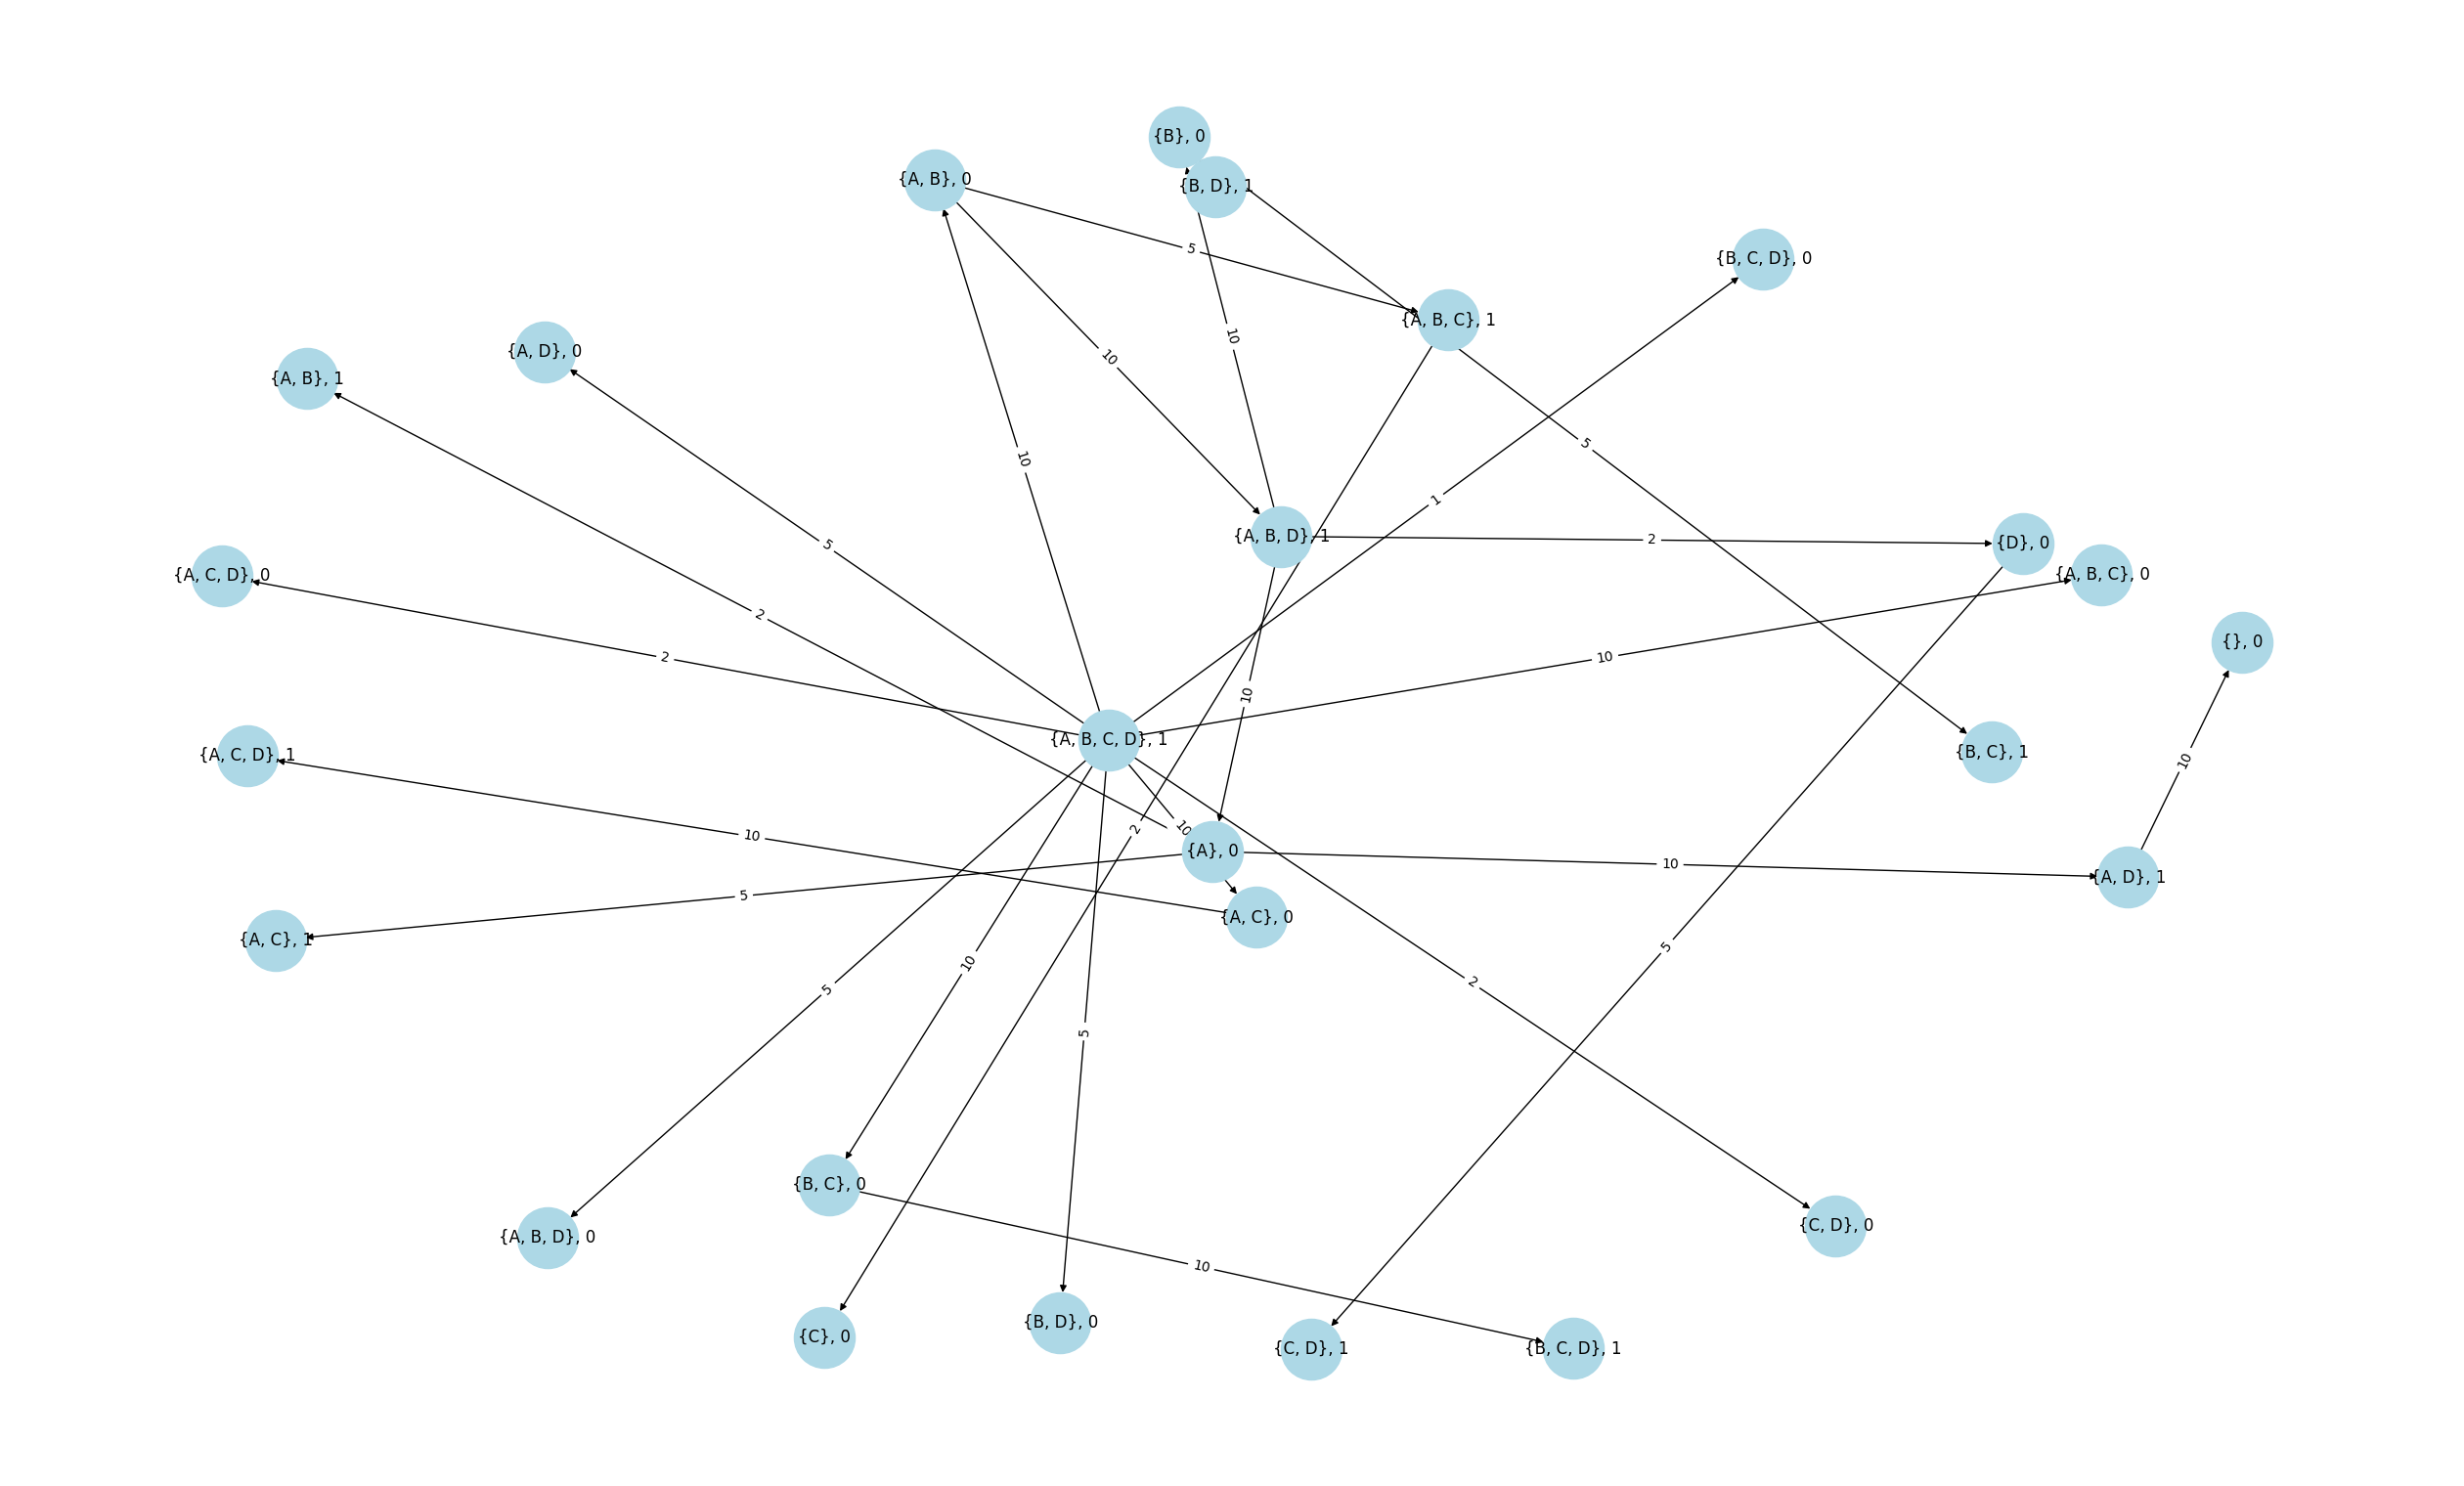

In [124]:
grafo_bfs, caminho, custo = bfs_com_grafo(estado_inicial, estado_objetivo)
grafo_bfs.show()

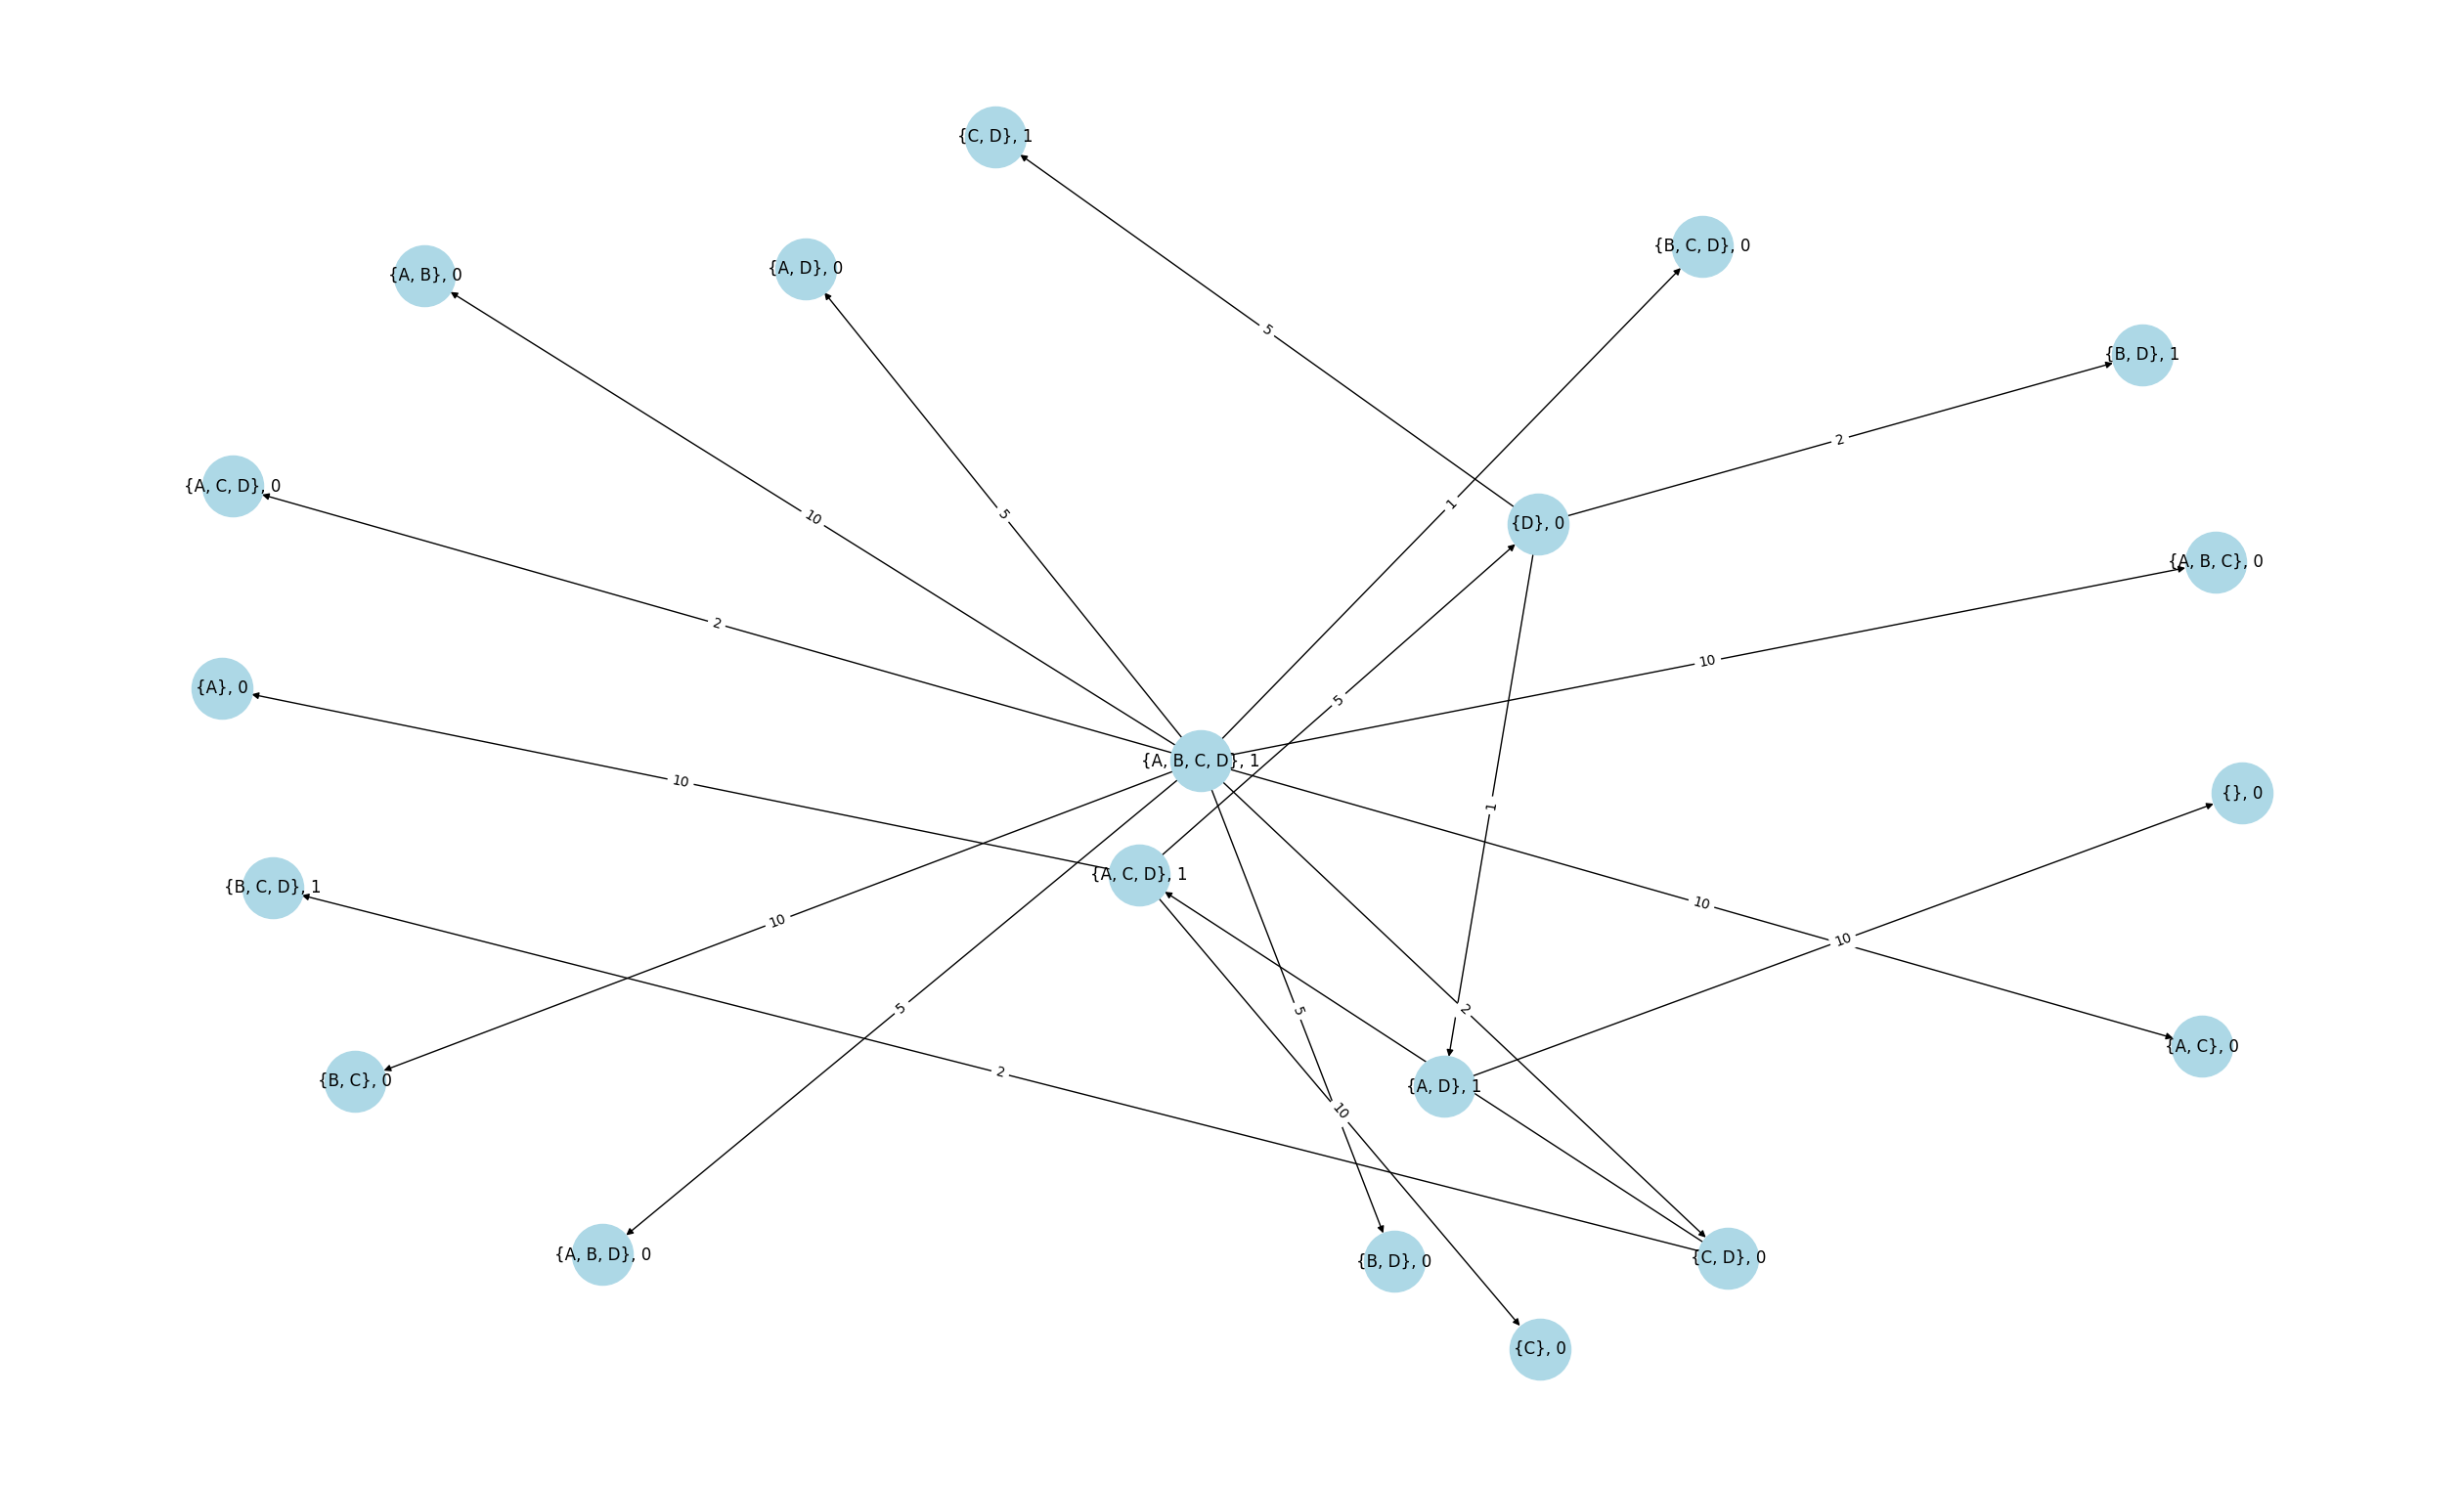

In [125]:
grafo_dfs, caminho, custo = dfs_com_grafo(estado_inicial, estado_objetivo)
grafo_dfs.show()

### Métodos de busca informada

In [126]:
# heuristica baseada no tempo do mais lento que ainda está no lado inicial
# logo o custo restante nunca pode ser menor que esse tempo
def heuristica_max_lento(estado):
    inicio, _ = estado
    if not inicio:
        return 0
    return max(TEMPOS[p] for p in inicio)

def custo_uniforme_com_grafo(estado_inicial, estado_objetivo):
    g = Grafo()
    heap = []
    heapq.heappush(heap, (0, estado_inicial, []))
    melhor_g = { (frozenset(estado_inicial[0]), estado_inicial[1]) : 0 }

    while heap:
        g_atual, estado, caminho = heapq.heappop(heap)
        label_atual = estado_to_label(estado)

        if estado == estado_objetivo:
            return g, caminho + [(estado, None, 0)], g_atual

        for s in construir_sucessores(estado):
            novo_estado = s["estado"]
            grupo = s["passageiros"]
            custo = s["custo"]
            label_novo = estado_to_label(novo_estado)

            g_novo = g_atual + int(custo)
            chave = (frozenset(novo_estado[0]), novo_estado[1])

            if chave not in melhor_g or g_novo < melhor_g[chave]:
                melhor_g[chave] = g_novo
                g.adicionar_aresta(label_atual, label_novo, custo)
                heapq.heappush(heap, (g_novo, novo_estado, caminho + [(estado, grupo, custo)]))

    return g, None, None

def a_estrela_com_grafo(estado_inicial, estado_objetivo, h_fn=heuristica_max_lento):
    g = Grafo()
    heap = []
    g0 = 0
    f0 = g0 + h_fn(estado_inicial)
    heapq.heappush(heap, (f0, g0, estado_inicial, []))
    melhor_g = { (frozenset(estado_inicial[0]), estado_inicial[1]) : 0 }

    while heap:
        f_atual, g_atual, estado, caminho = heapq.heappop(heap)
        label_atual = estado_to_label(estado)

        # garante consistência
        if f_atual != g_atual + h_fn(estado):
            continue

        if estado == estado_objetivo:
            return g, caminho + [(estado, None, 0)], g_atual

        for s in construir_sucessores(estado):
            novo_estado = s["estado"]
            grupo = s["passageiros"]
            custo = s["custo"]
            label_novo = estado_to_label(novo_estado)

            g_novo = g_atual + int(custo)
            chave = (frozenset(novo_estado[0]), novo_estado[1])

            if chave not in melhor_g or g_novo < melhor_g[chave]:
                melhor_g[chave] = g_novo
                f_novo = g_novo + h_fn(novo_estado)
                g.adicionar_aresta(label_atual, label_novo, custo)
                heapq.heappush(heap, (f_novo, g_novo, novo_estado, caminho + [(estado, grupo, custo)]))

    return g, None, None

In [ ]:
print("Custo Uniforme:")
grafo_cu, caminho, custo = custo_uniforme_com_grafo(estado_inicial, estado_objetivo)
grafo_cu.show()


print("\nA*:")
cam_a, custo_a = a_estrela_com_grafo(estado_inicial, estado_objetivo)
mostrar_caminho(cam_a, custo_a)


Custo Uniforme:


ValueError: too many values to unpack (expected 2)